# TSMC: SARIMA and SARIMAX forecasting experiments

**Status: built, not executed.** Run cells in order when you are ready. No fitted model, metrics, or plot outputs are supplied in this unexecuted notebook.

Predict the **next observed trading day's unadjusted closing price**, using information available after today's close. Compare all-usable-feature SARIMAX, training-selected-feature SARIMAX, and close-only SARIMA. Each configuration uses the same `(p,d,q) × (P,D,Q,m)` grid, chronological dates, and walk-forward protocol. Nonseasonal control candidates let the data challenge whether seasonality helps.

Ordinary SARIMA models one series. With `exog`, the model is SARIMAX: regression with seasonal ARIMA errors. `p,d,q` control ordinary autoregression, differencing, and moving-average errors; `P,D,Q` are their seasonal counterparts, and `m` is the seasonal lag in **observed trading rows**. The regression target is `Close[t+1]`, paired with `features[t]`. Tomorrow's unknown OHLCV values are never required.

The hypothesis `m=5` approximates a trading week. Holidays make it different from exact weekday seasonality. We do not insert weekend/holiday prices or assume seasonality must exist. Raw weekday/calendar columns in the all-feature experiment are ordinal numeric controls, not categorical weekday effects; their representation is a limitation. ACF and calendar plots provide training-only descriptive evidence.

**Provenance:** `features.ipynb` builds `Data/TSMC_Master_Features_15Y.csv` from the local Yahoo Finance file, with Google Finance comparisons in `validate.ipynb`. Record the original download method/date in the project report. `Adj Close` is excluded because point-in-time corporate-action adjustments are not documented.

This notebook covers forecasting and model saving. Profit maximization, Buy/Sell/Hold rules, trading execution, and transaction costs remain separate work. A forecasting winner is not necessarily the most profitable model.


## 1. Imports and experiment configuration

Dependencies: Python, NumPy, pandas, SciPy, Matplotlib, scikit-learn, Statsmodels, joblib, and IPython/Jupyter. Paths are relative to the discovered project root. Outputs are created under `models/sarima/<run_id>/` **only when this notebook is run**.

Four ordinary orders are crossed with four seasonal specifications, giving 16 candidates per feature configuration and 48 main fits. `(0,0,0,0)` disables seasonality; the other specifications test seasonal AR, seasonal MA, and seasonal differencing with seasonal MA at `m=5`. Ordinary differencing is fixed at `d=1`, as a prespecified price-model experiment. The training-only stationarity diagnostics explain its plausibility, not its universal optimality. The grid is deliberately smaller than the ARIMA grid because seasonal terms add dimensions and computational cost.

`D=0` and `D=1` are compared on validation. Seasonal differencing can over-difference a series; it is not automatically appropriate. No deterministic drift is included. Parameters are fitted once at each evaluation origin. Each subsequent forecast updates the state with the newly observed target, without daily coefficient refitting. All configurations share this protocol.

Feature selection uses a separate chronological cross-validation entirely inside training. It never sees validation or test targets. This selector is a predictive screening method, not proof of statistical significance or optimal SARIMAX features.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import time
import warnings
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
from IPython.display import display, Markdown
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.exceptions import ConvergenceWarning
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'Data' / 'TSMC_Master_Features_15Y.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Start Jupyter inside the project containing Data/TSMC_Master_Features_15Y.csv.')
DATA_FILE = ROOT / 'Data' / 'TSMC_Master_Features_15Y.csv'
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
RUN_DIR = ROOT / 'models' / 'sarima' / RUN_ID
PLOT_DIR = RUN_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=False)

TRAIN_FRACTION, VALIDATION_FRACTION = 0.70, 0.15
ORDER_GRID = [(0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1)]
SEASON_LENGTH = 5
SEASONAL_GRID = [(0, 0, 0, 0), (1, 0, 0, SEASON_LENGTH),
                 (0, 0, 1, SEASON_LENGTH), (0, 1, 1, SEASON_LENGTH)]
MODEL_GRID = [(order, seasonal) for order in ORDER_GRID for seasonal in SEASONAL_GRID]
SELECTOR_ALPHAS = [1e-5, 1e-4, 1e-3, 1e-2]
SELECTOR_L1_RATIOS = [0.2, 0.5, 0.9, 1.0]
SELECTOR_COEF_TOL = 1e-8
MAX_ITER = 250
TREND = 'n'
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 12})
pd.set_option('display.max_columns', 20)

def finish_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Project:', ROOT)
print('Outputs:', RUN_DIR)
print('Candidate fits:', len(MODEL_GRID) * 3)


Project: f:\SEM-7\Time Series Analysis\Project
Outputs: f:\SEM-7\Time Series Analysis\Project\models\sarima\20260923T033954075995Z
Candidate fits: 48


## 2. Load and audit the master data

Sort dates, reject duplicate dates and non-finite values, and verify elementary OHLC consistency. Missing values from lag/rolling warm-up are expected; we remove incomplete input rows rather than backfilling from the future. We explicitly check that the master features were calculated with trailing windows and past lags.

**Feature availability:** a forecast is issued after day `t` closes. Day `t` OHLCV and its trailing indicators are then observable. `Date` is an index, not a numeric explanatory variable. `Adj Close` is excluded from both feature experiments because a current historical download may retroactively incorporate later corporate actions; this file does not document point-in-time adjusted values. Thus “all features” means **all usable, causally available numeric features**, with this exclusion disclosed. Raw `Close` and its trailing transforms are available at the forecast origin and are valid inputs for `Close[t+1]`.


In [2]:
raw = pd.read_csv(DATA_FILE)
raw['Date'] = pd.to_datetime(raw['Date'], errors='raise')
raw = raw.sort_values('Date').reset_index(drop=True)
assert raw['Date'].notna().all() and raw['Date'].is_unique, 'Missing or duplicate dates.'
assert raw['Date'].is_monotonic_increasing
numeric_columns = raw.columns.drop('Date').tolist()
raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors='raise')
assert not np.isinf(raw[numeric_columns].to_numpy()).any(), 'Infinite data values.'
assert (raw['Close'] > 0).all() and (raw['Volume'] >= 0).all()
tol = 1e-5
assert (raw['High'] + tol >= raw[['Open', 'Close', 'Low']].max(axis=1)).all()
assert (raw['Low'] - tol <= raw[['Open', 'Close', 'High']].min(axis=1)).all()

expected = {
    'Log_Close': np.log(raw['Close']),
    'Return_1D': raw['Close'].pct_change(fill_method=None),
    'Log_Return_1D': np.log(raw['Close']).diff(),
    'High_Low_Range': (raw['High'] - raw['Low']) / raw['Close'],
    'Open_Close_Change': (raw['Close'] - raw['Open']) / raw['Open'],
    'Day_of_Week': raw['Date'].dt.dayofweek,
    'Month': raw['Date'].dt.month, 'Quarter': raw['Date'].dt.quarter,
    'Year': raw['Date'].dt.year,
}
for lag in [1, 2, 3, 5, 10, 20]:
    expected[f'Close_Lag_{lag}'] = raw['Close'].shift(lag)
    expected[f'Return_Lag_{lag}'] = expected['Return_1D'].shift(lag)
for window in [5, 10, 20, 50]:
    expected[f'SMA_{window}'] = raw['Close'].rolling(window).mean()
for window in [5, 10, 20]:
    expected[f'Volatility_{window}'] = expected['Log_Return_1D'].rolling(window).std()
    expected[f'Momentum_{window}D'] = raw['Close'].pct_change(window, fill_method=None)
for name, values in expected.items():
    np.testing.assert_allclose(raw[name], values, rtol=1e-6, atol=1e-8,
                               equal_nan=True, err_msg=f'Feature mismatch: {name}')

audit = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum()})
display(audit)
print(f'{len(raw):,} rows; {len(raw.columns)} columns; '
      f"{raw['Date'].min().date()} through {raw['Date'].max().date()}")
print('Verified all engineered columns against causal trailing calculations.')
audit.to_csv(RUN_DIR / 'data_audit.csv')


,dtype,missing
Date,datetime64[ns],0
Open,float64,0
High,float64,0
Low,float64,0
Close,float64,0
Adj Close,float64,0
Volume,int64,0
Log_Close,float64,0
Return_1D,float64,1
Log_Return_1D,float64,1


3,771 rows; 38 columns; 2011-09-12 through 2026-09-10
Verified all engineered columns against causal trailing calculations.


## 3. Align targets and preserve comparable chronological splits

`Target_Close = Close.shift(-1)` pairs origin-day features with the next trading day's close. `Origin_Date` and `Target_Date` are exported separately. All models use identical complete rows, including the same rolling-feature warm-up exclusion as the ARIMA notebook. Keep 70% training, 15% validation, and the final 15% for testing. Splits are ordered by target date, with no shuffling.

Feature configurations are defined after the training-only selection step below:

- **SARIMAX_all:** every usable original numeric master feature except `Adj Close` (36 for the current file).
- **SARIMAX_selected:** a subset screened from that full pool using only training-period chronological folds.
- **SARIMA_close_only:** target history without exogenous features.

This avoids fixing eight supposedly optimal features in advance. It is acceptable if screening retains many inputs or no inputs: the selected list is data-dependent, and an empty list reduces that configuration to close-only SARIMA. The all-feature configuration remains an explicit experiment with redundant inputs.


,split,rows,first_origin,last_origin,first_target,last_target
0,train,2604,2011-11-18,2022-03-25,2011-11-21,2022-03-28
1,validation,558,2022-03-28,2024-06-14,2022-03-29,2024-06-17
2,test,559,2024-06-17,2026-09-09,2024-06-18,2026-09-10


,Origin_Date,Close,Target_Date,Target_Close
0,2011-11-18,12.66,2011-11-21,12.56
1,2011-11-21,12.56,2011-11-22,12.56
2,2011-11-22,12.56,2011-11-23,12.20
3,2011-11-23,12.20,2011-11-25,12.07
4,2011-11-25,12.07,2011-11-28,12.55


All usable exogenous features: 36
Rows omitted for warm-up or unknown final target: 50


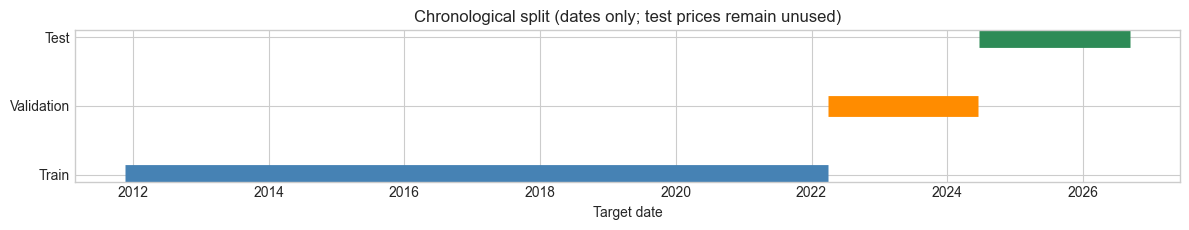

In [3]:
EXCLUDED = {'Date': 'Timestamp/index',
            'Adj Close': 'No point-in-time corporate-action adjustment provenance'}
ALL_FEATURES = [c for c in numeric_columns if c not in EXCLUDED]
aligned = raw.rename(columns={'Date': 'Origin_Date'}).copy()
aligned['Target_Date'] = aligned['Origin_Date'].shift(-1)
aligned['Target_Close'] = aligned['Close'].shift(-1)
data = aligned.dropna(subset=ALL_FEATURES + ['Target_Date', 'Target_Close']).reset_index(drop=True)
assert len(data) > 500, 'Insufficient complete observations for this experiment.'
assert (data['Origin_Date'] < data['Target_Date']).all()
assert data['Target_Date'].is_unique

n = len(data)
train_end = int(n * TRAIN_FRACTION)
validation_end = int(n * (TRAIN_FRACTION + VALIDATION_FRACTION))
train = data.iloc[:train_end].copy()
validation = data.iloc[train_end:validation_end].copy()
test = data.iloc[validation_end:].copy()
assert train['Target_Date'].max() < validation['Target_Date'].min()
assert validation['Target_Date'].max() < test['Target_Date'].min()
# By each forecast origin, the preceding target has already become observable.
assert train['Target_Date'].iloc[-1] <= validation['Origin_Date'].iloc[0]
assert validation['Target_Date'].iloc[-1] <= test['Origin_Date'].iloc[0]

split_summary = pd.DataFrame([
    {'split': name, 'rows': len(frame),
     'first_origin': frame['Origin_Date'].min(), 'last_origin': frame['Origin_Date'].max(),
     'first_target': frame['Target_Date'].min(), 'last_target': frame['Target_Date'].max()}
    for name, frame in [('train', train), ('validation', validation), ('test', test)]
])
display(split_summary)
display(data[['Origin_Date', 'Close', 'Target_Date', 'Target_Close']].head())
print('All usable exogenous features:', len(ALL_FEATURES))
print('Rows omitted for warm-up or unknown final target:', len(raw) - len(data))
split_summary.to_csv(RUN_DIR / 'splits.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 2.4))
for y, (name, frame, color) in enumerate([
        ('Train', train, 'steelblue'), ('Validation', validation, 'darkorange'),
        ('Test', test, 'seagreen')]):
    ax.plot([frame['Target_Date'].min(), frame['Target_Date'].max()], [y, y],
            linewidth=15, solid_capstyle='butt', color=color)
ax.set(yticks=[0, 1, 2], yticklabels=['Train', 'Validation', 'Test'],
       xlabel='Target date', title='Chronological split (dates only; test prices remain unused)')
finish_plot('01_chronological_split')


## 4. Training-only stationarity and seasonal diagnostics

Price, return, correlation, ACF, and PACF plots use training observations only. ADF tests a unit-root null; KPSS tests a level-stationarity null. Their p-values help interpret differencing but do not prove predictability or seasonality. We compare raw close, first difference, seasonal difference at lag five, and both differences.

Return autocorrelation is examined at lags 5, 10, 21, and 252 (approximate trading-week/month/year scales). These are descriptive lags, not a calendar guarantee or an automatic rule for choosing `m`. Weekday/month plots summarize observed training returns; apparent differences can be sampling noise. The validation grid compares seasonal terms against an explicit nonseasonal control.


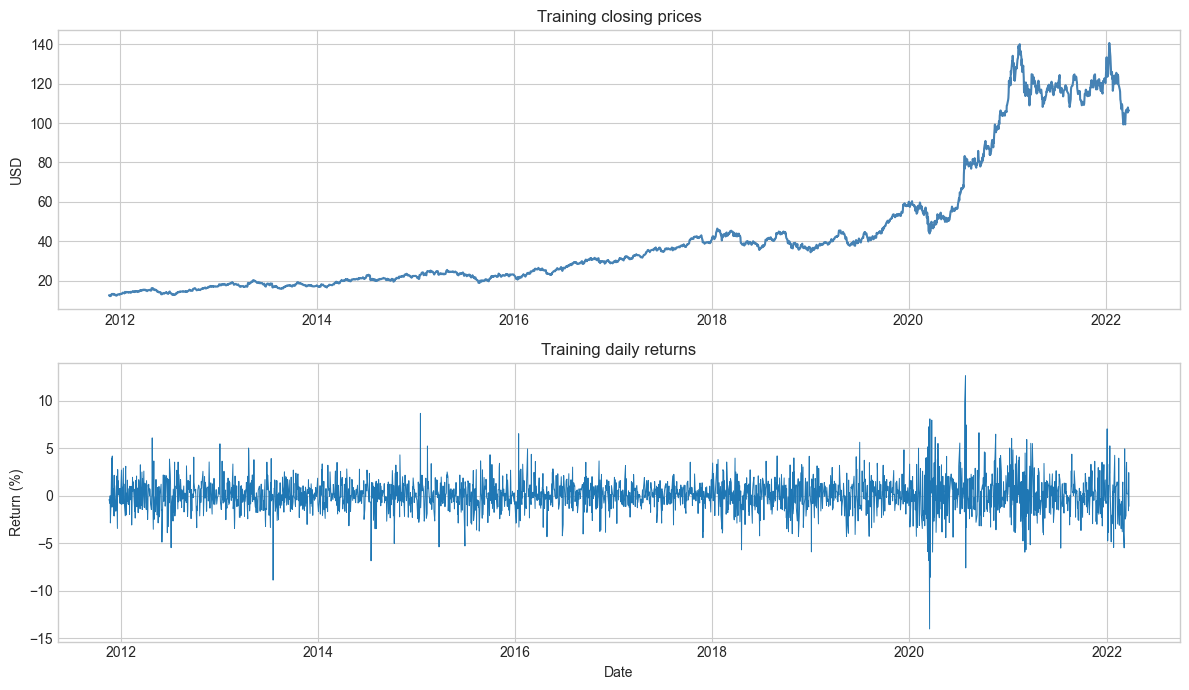

,series,ADF statistic,ADF p,KPSS statistic,KPSS p,KPSS note
0,Close,0.101947,9.661938e-01,6.213305,0.01,The test statistic is outside of the range of ...
1,First difference,-9.407810,5.945936e-16,0.205402,0.10,The test statistic is outside of the range of ...
2,Seasonal difference,-8.429617,1.885602e-13,0.242272,0.10,The test statistic is outside of the range of ...
3,Both differences,-17.756719,3.351945e-30,0.042195,0.10,The test statistic is outside of the range of ...


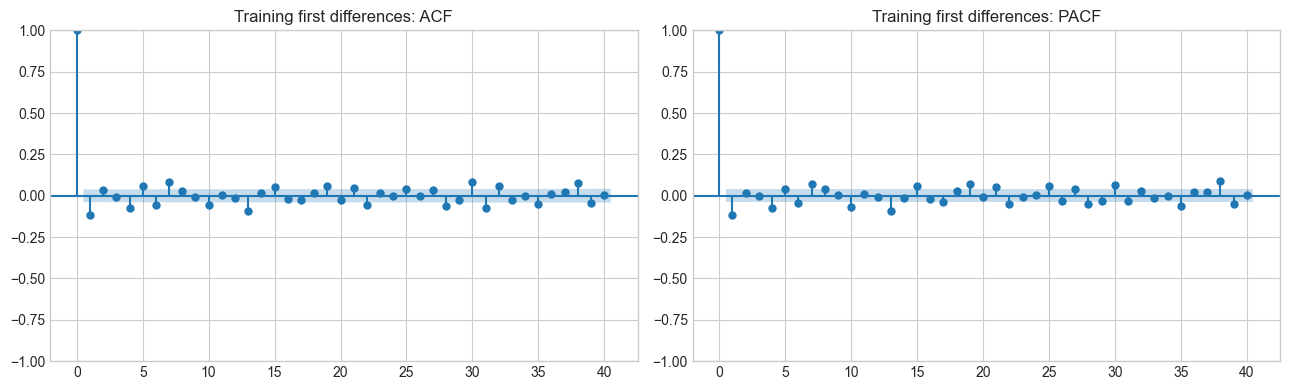

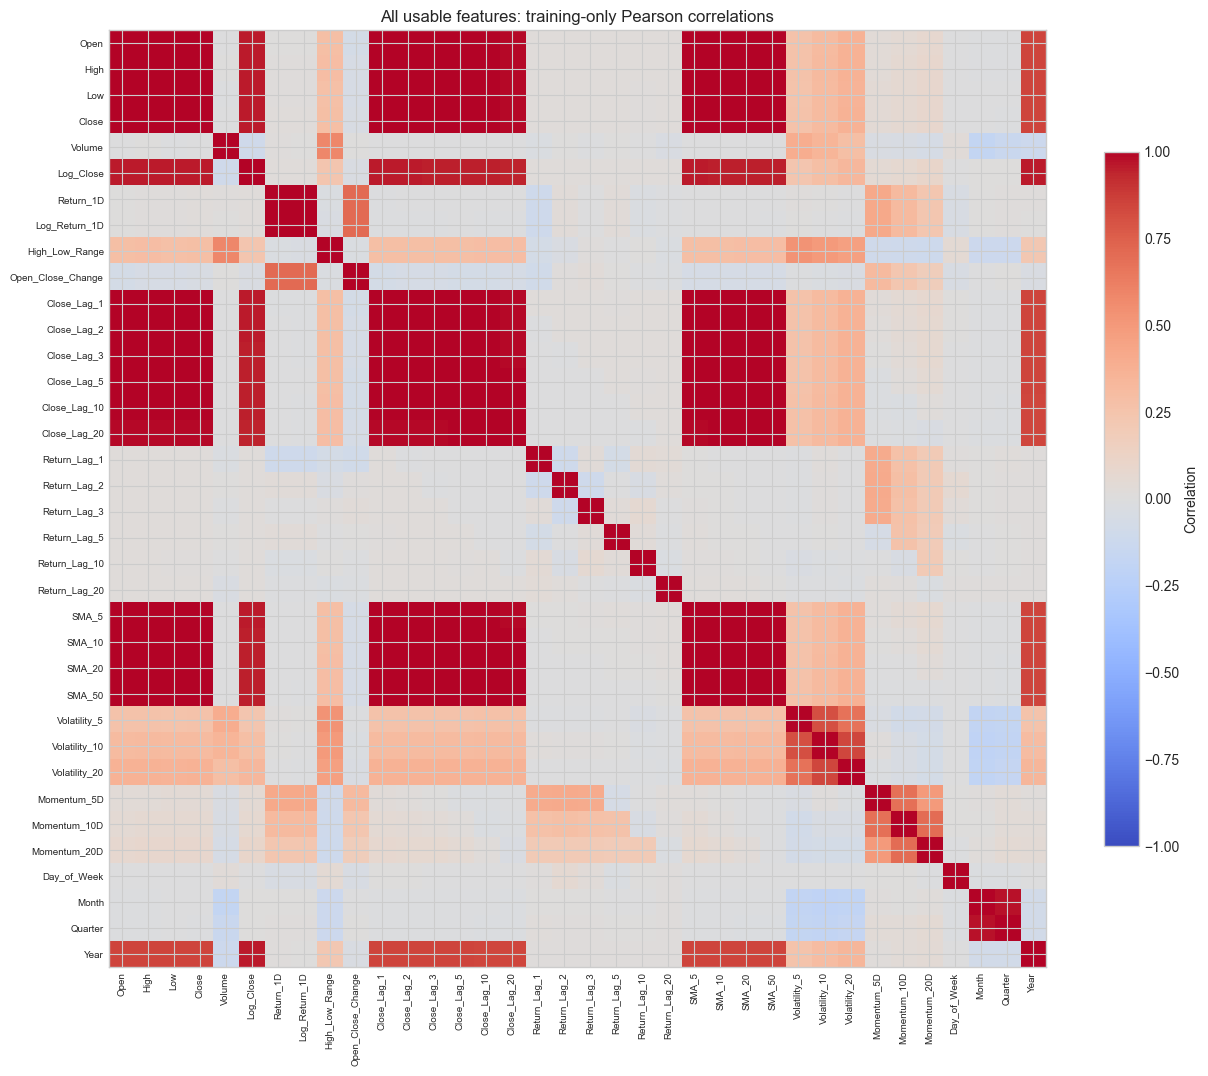

,lag_in_trading_rows,return_ACF
0,5,0.024470
1,10,-0.025810
2,21,0.027618
3,252,-0.017268


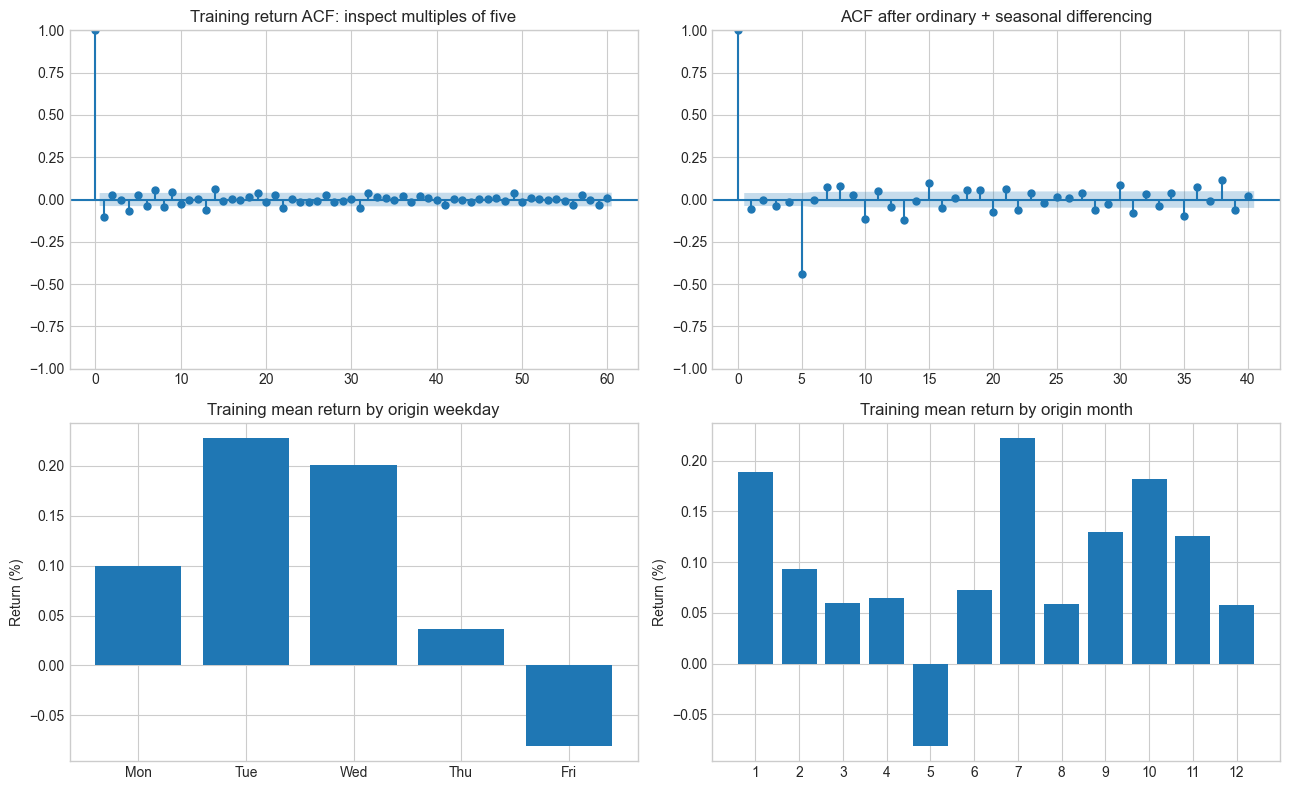

In [4]:
series = train['Target_Close']
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(train['Target_Date'], series, color='steelblue')
axes[0].set(title='Training closing prices', ylabel='USD')
axes[1].plot(train['Origin_Date'], train['Return_1D'] * 100, linewidth=0.7)
axes[1].set(title='Training daily returns', xlabel='Date', ylabel='Return (%)')
finish_plot('02_training_series')

stationarity_rows = []
for label, values in [('Close', series), ('First difference', series.diff().dropna()),
                      ('Seasonal difference', series.diff(SEASON_LENGTH).dropna()),
                      ('Both differences', series.diff().diff(SEASON_LENGTH).dropna())]:
    adf = adfuller(values, autolag='AIC')
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        kp = kpss(values, regression='c', nlags='auto')
    stationarity_rows.append({'series': label, 'ADF statistic': adf[0], 'ADF p': adf[1],
                             'KPSS statistic': kp[0], 'KPSS p': kp[1],
                             'KPSS note': '; '.join(str(w.message) for w in caught)})
stationarity = pd.DataFrame(stationarity_rows)
display(stationarity)
stationarity.to_csv(RUN_DIR / 'stationarity.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(series.diff().dropna(), lags=40, ax=axes[0])
plot_pacf(series.diff().dropna(), lags=40, method='ywm', ax=axes[1])
axes[0].set_title('Training first differences: ACF')
axes[1].set_title('Training first differences: PACF')
finish_plot('03_training_acf_pacf')

correlations = train[ALL_FEATURES].corr()
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(correlations, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(ALL_FEATURES)), ALL_FEATURES, rotation=90, fontsize=7)
ax.set_yticks(range(len(ALL_FEATURES)), ALL_FEATURES, fontsize=7)
ax.set_title('All usable features: training-only Pearson correlations')
fig.colorbar(im, ax=ax, shrink=0.7, label='Correlation')
finish_plot('04_training_feature_correlations')


from statsmodels.tsa.stattools import acf
training_returns = train['Return_1D'].to_numpy()
seasonal_lags = [5, 10, 21, 252]
return_acf = acf(training_returns, nlags=max(seasonal_lags), fft=True)
seasonality_table = pd.DataFrame({'lag_in_trading_rows': seasonal_lags,
                                  'return_ACF': [return_acf[lag] for lag in seasonal_lags]})
display(seasonality_table)
seasonality_table.to_csv(RUN_DIR / 'training_seasonal_acf.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_acf(training_returns, lags=60, ax=axes[0, 0])
axes[0, 0].set_title('Training return ACF: inspect multiples of five')
plot_acf(series.diff().diff(SEASON_LENGTH).dropna(), lags=40, ax=axes[0, 1])
axes[0, 1].set_title('ACF after ordinary + seasonal differencing')
weekday_stats = train.groupby('Day_of_Week')['Return_1D'].agg(['mean', 'count', 'std'])
month_stats = train.groupby('Month')['Return_1D'].agg(['mean', 'count', 'std'])
axes[1, 0].bar(weekday_stats.index, weekday_stats['mean'] * 100)
axes[1, 0].set(xticks=range(5), xticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
               title='Training mean return by origin weekday', ylabel='Return (%)')
axes[1, 1].bar(month_stats.index, month_stats['mean'] * 100)
axes[1, 1].set(xticks=range(1, 13), title='Training mean return by origin month', ylabel='Return (%)')
finish_plot('04b_training_seasonality')
weekday_stats.to_csv(RUN_DIR / 'training_weekday_returns.csv')
month_stats.to_csv(RUN_DIR / 'training_month_returns.csv')


## 5. Select explanatory features using training data only

Instead of manually fixing eight columns, screen **all usable original features** with Elastic Net. This linear model penalizes coefficient size; its L1 component can set coefficients to zero, while its L2 component can help with correlated inputs. Correlated variables can still substitute for each other: selection is predictive screening, not causal evidence or a significance test.

The screening target is next-day **return**, `(Target_Close / Close) - 1`, so persistent price levels do not dominate feature selection just by tracking a trend. The final SARIMAX target remains the next-day **price**. This is a proxy screening task, not exhaustive subset selection for SARIMAX itself.

Three expanding training folds and a one-row gap choose penalty strength and mixing ratio by mean squared error. Each fold fits its own constant-feature filter and scaler. `Volume` receives the deterministic `log1p` transform. A one-row gap is a conservative buffer for the next-day target. The selected penalty is refitted on the whole training period; only columns with nonzero coefficients survive. The feature list is then frozen through SARIMAX validation and final refitting. No statistical-significance claims are made from these coefficients.

Each fold fit must converge. An unconverged fit makes that candidate ineligible (its mean CV score becomes NaN); other candidates can still compete. The selected candidate must also converge when refitted on all training observations, otherwise execution stops. Failed-fit diagnostics are retained. If screening selects nothing, retain the empty list and report it honestly. The regularized procedure may retain correlated features; condition-number diagnostics below provide additional context.


,fold,fit_rows,holdout_rows,fit_last_target,holdout_first_origin
0,1,650,651,2014-06-24,2014-06-25
1,2,1301,651,2017-01-24,2017-01-25
2,3,1952,651,2019-08-26,2019-08-27


Excluded 1 / 16 selector candidates due to failed CV fits.
Candidate failure details are saved in feature_selection_warnings.json.


,feature,standardized_coefficient,selected,reason
0,Open,-0.000000,False,Zero/near-zero coefficient or constant in full...
1,High,-0.000000,False,Zero/near-zero coefficient or constant in full...
2,Low,-0.000000,False,Zero/near-zero coefficient or constant in full...
3,Close,-0.000000,False,Zero/near-zero coefficient or constant in full...
4,Volume,-0.000000,False,Zero/near-zero coefficient or constant in full...
5,Log_Close,-0.000000,False,Zero/near-zero coefficient or constant in full...
6,Return_1D,-0.000000,False,Zero/near-zero coefficient or constant in full...
7,Log_Return_1D,-0.000583,True,Nonzero regularized coefficient
8,High_Low_Range,-0.000000,False,Zero/near-zero coefficient or constant in full...
9,Open_Close_Change,-0.000557,True,Nonzero regularized coefficient


Selector settings: {'elastic_net__alpha': 0.001, 'elastic_net__l1_ratio': 0.9}
Selected features: ['Log_Return_1D', 'Open_Close_Change', 'Return_Lag_3']


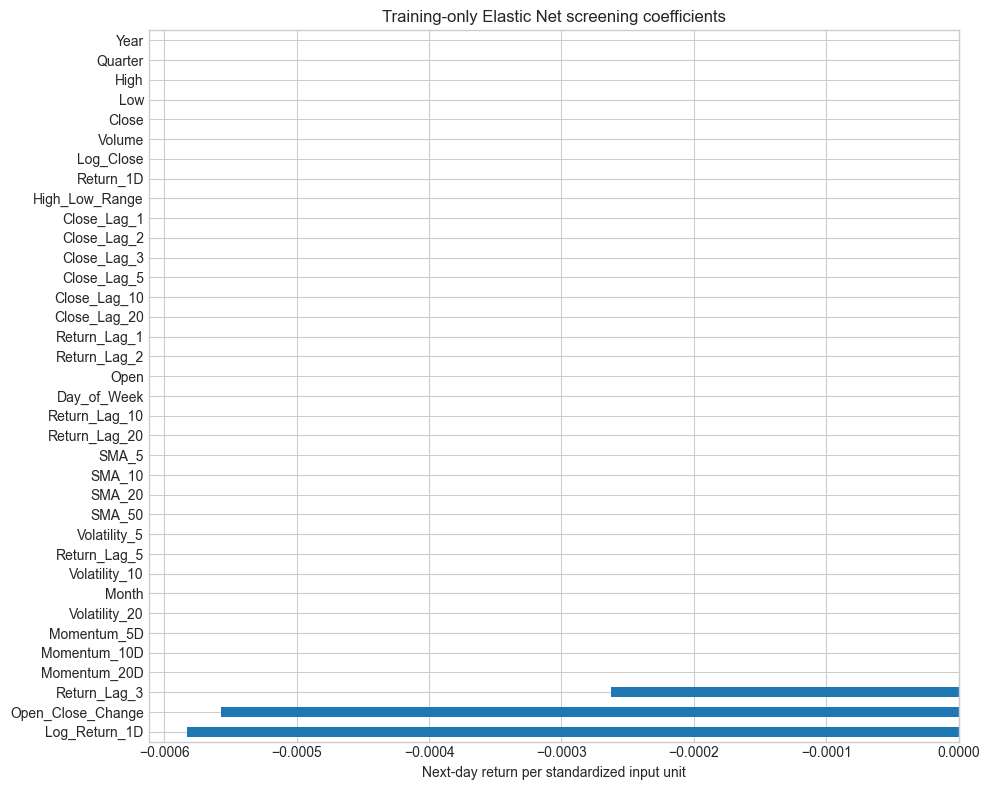

In [5]:
def feature_values(frame, columns):
    values = frame[columns].astype(float).copy()
    if 'Volume' in columns:
        values['Volume'] = np.log1p(values['Volume'])
    return values.to_numpy(dtype=float)

selector_x = feature_values(train, ALL_FEATURES)
selector_y = (train['Target_Close'] / train['Close'] - 1).to_numpy()
selector_cv = TimeSeriesSplit(n_splits=3, gap=1)
fold_rows = []
for fold, (fit_idx, holdout_idx) in enumerate(selector_cv.split(selector_x), start=1):
    assert train.iloc[fit_idx]['Target_Date'].max() < train.iloc[holdout_idx]['Origin_Date'].min()
    fold_rows.append({'fold': fold, 'fit_rows': len(fit_idx), 'holdout_rows': len(holdout_idx),
                     'fit_last_target': train.iloc[fit_idx]['Target_Date'].max(),
                     'holdout_first_origin': train.iloc[holdout_idx]['Origin_Date'].min()})
display(pd.DataFrame(fold_rows))
pd.DataFrame(fold_rows).to_csv(RUN_DIR / 'feature_selection_folds.csv', index=False)

class ConvergenceCheckedElasticNet(ElasticNet):
    """Reject an unconverged fit so GridSearchCV cannot rank it as valid."""
    def fit(self, X, y, sample_weight=None, check_input=True):
        with warnings.catch_warnings(record=True) as fit_warnings:
            warnings.simplefilter('always')
            super().fit(X, y, sample_weight=sample_weight, check_input=check_input)
        convergence_messages = [str(w.message) for w in fit_warnings
                                if issubclass(w.category, ConvergenceWarning)]
        for warning in fit_warnings:
            if not issubclass(warning.category, ConvergenceWarning):
                warnings.warn(str(warning.message), warning.category)
        if convergence_messages:
            raise ValueError(
                f'Elastic Net did not converge: alpha={self.alpha}, '
                f'l1_ratio={self.l1_ratio}. ' + ' | '.join(convergence_messages))
        if not np.isfinite(self.coef_).all() or not np.isfinite(self.intercept_):
            raise ValueError('Elastic Net produced non-finite coefficients.')
        return self

selector_pipeline = Pipeline([
    ('nonconstant', VarianceThreshold()),
    ('scale', StandardScaler()),
    ('elastic_net', ConvergenceCheckedElasticNet(max_iter=50000, tol=1e-5, selection='cyclic')),
])
selector_search = GridSearchCV(
    selector_pipeline,
    {'elastic_net__alpha': SELECTOR_ALPHAS, 'elastic_net__l1_ratio': SELECTOR_L1_RATIOS},
    scoring='neg_mean_squared_error', cv=selector_cv, refit=True,
    n_jobs=1, error_score=np.nan, return_train_score=True,
)
with warnings.catch_warnings(record=True) as selector_warnings:
    warnings.simplefilter('always')
    try:
        selector_search.fit(selector_x, selector_y)
    finally:
        # Persist failures even if all candidates fail or the final refit fails.
        (RUN_DIR / 'feature_selection_warnings.json').write_text(
            json.dumps(list(dict.fromkeys(str(w.message) for w in selector_warnings)), indent=2),
            encoding='utf-8')
selector_warning_text = list(dict.fromkeys(str(w.message) for w in selector_warnings))
selector_cv_results = pd.DataFrame(selector_search.cv_results_)
selector_cv_results.to_csv(RUN_DIR / 'feature_selection_cv.csv', index=False)
(RUN_DIR / 'feature_selection_warnings.json').write_text(
    json.dumps(selector_warning_text, indent=2), encoding='utf-8')
if not np.isfinite(selector_search.best_score_):
    raise RuntimeError('No selector candidate passed every CV fold. Inspect the saved diagnostics.')
rejected_count = int((~np.isfinite(selector_cv_results['mean_test_score'])).sum())
print(f'Excluded {rejected_count} / {len(selector_cv_results)} selector candidates due to failed CV fits.')
if rejected_count:
    print('Candidate failure details are saved in feature_selection_warnings.json.')
selector_best = selector_search.best_estimator_
retained_names = np.asarray(ALL_FEATURES)[selector_best.named_steps['nonconstant'].get_support()]
coefficient_series = pd.Series(selector_best.named_steps['elastic_net'].coef_, index=retained_names)
selection_table = pd.DataFrame({'feature': ALL_FEATURES})
selection_table['standardized_coefficient'] = selection_table['feature'].map(coefficient_series).fillna(0.0)
selection_table['selected'] = selection_table['standardized_coefficient'].abs() > SELECTOR_COEF_TOL
selection_table['reason'] = np.where(selection_table['selected'], 'Nonzero regularized coefficient',
                                    'Zero/near-zero coefficient or constant in full training period')
SELECTED_FEATURES = selection_table.loc[selection_table['selected'], 'feature'].tolist()
FEATURE_SETS = {'SARIMAX_all': ALL_FEATURES,
                'SARIMAX_selected': SELECTED_FEATURES,
                'SARIMA_close_only': []}
display(selection_table)
print('Selector settings:', selector_search.best_params_)
print('Selected features:', SELECTED_FEATURES)
if not SELECTED_FEATURES:
    print('No input survived screening; the selected-feature configuration equals close-only SARIMA.')
selection_table.to_csv(RUN_DIR / 'feature_selection.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 8))
selection_table.set_index('feature')['standardized_coefficient'].sort_values().plot.barh(ax=ax)
ax.set(title='Training-only Elastic Net screening coefficients',
       xlabel='Next-day return per standardized input unit', ylabel='')
finish_plot('04c_feature_selection')


## 6. SARIMAX estimation and walk-forward helper functions

`prepare_inputs` fits scaling on the current fit period and applies it to the later period. `fit_candidate` fits the requested ordinary and seasonal orders with the same settings for each feature configuration. `simple_differencing=False` retains the integrated state-space formulation so forecasts remain on the original price scale. Warnings and convergence are recorded.

`walk_forward` predicts one observation before revealing its actual target. It then calls `extend` with that actual and the matching exogenous row. Coefficients stay fixed; latent states update. No future market features are supplied.

MAE and RMSE are in dollars, MSE in squared dollars, MAPE in percent. R² measures price-level fit and can look strong even for persistence. MASE uses the fit-period persistence MAE as its scale. RMSE skill is percentage improvement over persistence on identical evaluation dates. Direction accuracy compares signs of changes from the known origin close, counting zero as its own direction.

Report rank and condition numbers for original standardized designs and for their first differences. These are descriptive collinearity checks; they do not certify every seasonal specification's identifiability. A random-walk timing assertion is included for when the notebook is executed.


In [6]:
def prepare_inputs(fit_frame, later_frame, columns):
    if not columns:
        return None, None, None
    scaler = StandardScaler()
    x_fit = scaler.fit_transform(feature_values(fit_frame, columns))
    x_later = scaler.transform(feature_values(later_frame, columns))
    assert np.isfinite(x_fit).all() and np.isfinite(x_later).all()
    return x_fit, x_later, scaler

def fit_candidate(y, x, order, seasonal_order=(0, 0, 0, 0)):
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        fitted = SARIMAX(np.asarray(y, dtype=float), exog=x, order=order,
                         seasonal_order=seasonal_order, trend=TREND,
                         enforce_stationarity=True, enforce_invertibility=True,
                         simple_differencing=False, concentrate_scale=False).fit(
            method='lbfgs', maxiter=MAX_ITER, disp=False, cov_type='none')
    convergence = bool(fitted.mle_retvals.get('converged', False))
    messages = list(dict.fromkeys(str(w.message) for w in caught))
    return fitted, convergence, messages, time.perf_counter() - started

def walk_forward(fitted, later_frame, x_later, intervals=False):
    state = fitted
    predictions, lower, upper = [], [], []
    for i in range(len(later_frame)):
        x_next = None if x_later is None else x_later[i:i + 1]
        forecast = state.get_forecast(steps=1, exog=x_next)
        predictions.append(float(np.asarray(forecast.predicted_mean).reshape(-1)[0]))
        if intervals:
            bounds = np.asarray(forecast.conf_int(alpha=0.05)).reshape(-1)
            lower.append(float(bounds[0]))
            upper.append(float(bounds[1]))
        # Observe the realization only AFTER producing its forecast.
        observed = float(later_frame['Target_Close'].iloc[i])
        state = state.extend(endog=np.array([observed]), exog=x_next)
    predictions = np.asarray(predictions)
    if not np.isfinite(predictions).all():
        raise ValueError('Non-finite forecasts.')
    return predictions, np.asarray(lower), np.asarray(upper)

def score(frame, predictions, fit_frame):
    actual = frame['Target_Close'].to_numpy(dtype=float)
    origin = frame['Close'].to_numpy(dtype=float)
    predictions = np.asarray(predictions, dtype=float)
    assert actual.shape == predictions.shape and np.isfinite(predictions).all()
    mae = mean_absolute_error(actual, predictions)
    mse = mean_squared_error(actual, predictions)
    baseline_rmse = np.sqrt(mean_squared_error(actual, origin))
    scale = np.mean(np.abs(fit_frame['Target_Close'] - fit_frame['Close']))
    return {'MAE': mae, 'MSE': mse, 'RMSE': np.sqrt(mse),
            'MAPE_pct': np.mean(np.abs((actual - predictions) / actual)) * 100,
            'R2': r2_score(actual, predictions), 'MASE': mae / scale if scale > 0 else np.nan,
            'Direction_accuracy_pct': np.mean(np.sign(predictions - origin) ==
                                               np.sign(actual - origin)) * 100,
            'RMSE_skill_pct': (1 - np.sqrt(mse) / baseline_rmse) * 100 if baseline_rmse > 0 else np.nan}

# A random walk without drift must reproduce persistence in walk-forward mode.
smoke_frame = pd.DataFrame({'Target_Close': [14., 13., 16.]})
smoke_fit, _, _, _ = fit_candidate(np.array([10., 11., 9., 12.]), None, (0, 1, 0))
smoke_predictions, _, _ = walk_forward(smoke_fit, smoke_frame, None)
np.testing.assert_allclose(smoke_predictions, [12., 14., 13.], atol=1e-6)
print('Forecast-before-observe timing check passed.')

design_rows = []
for name, columns in FEATURE_SETS.items():
    if columns:
        x, _, _ = prepare_inputs(train, validation, columns)
        design_rows.append({'configuration': name, 'features': len(columns),
                            'rank': np.linalg.matrix_rank(x),
                            'condition_number': np.linalg.cond(x),
                            'differenced_rank': np.linalg.matrix_rank(np.diff(x, axis=0)),
                            'differenced_condition_number': np.linalg.cond(np.diff(x, axis=0))})
design_diagnostics = pd.DataFrame(design_rows)
display(design_diagnostics)
design_diagnostics.to_csv(RUN_DIR / 'design_diagnostics.csv', index=False)


Forecast-before-observe timing check passed.


,configuration,features,rank,condition_number,differenced_rank,differenced_condition_number
0,SARIMAX_all,36,36,1537.604605,36,945.804627
1,SARIMAX_selected,3,3,2.398813,3,2.516098


## 7. Common ordinary × seasonal grid on validation

Every configuration is evaluated on the same 16 order pairs. Candidate keys contain both orders, avoiding accidental overwrites. Failed or nonconverged fits are recorded and excluded from selection. Results are checkpointed after each fit. Nonconverged fits are not walked forward, which avoids spending time on ineligible forecasts.

Compare with ordinary persistence and seasonal persistence. Seasonal persistence predicts `Close[u]` using `Close[u-5]` for target row `u`; at an origin row `t=u-1`, this is the master feature `Close_Lag_4`, which is constructed explicitly here because the master file does not contain it. It is **not** `Close_Lag_5` at the origin. Both baselines use only observations already available.

The runtime can be substantial: 48 model fits plus one-step validation forecasts. This notebook was built without running those computations. Do not choose features, periods, or grid changes from test results.


In [7]:
records = []
validation_forecasts = {}
metric_names = ['MAE', 'MSE', 'RMSE', 'MAPE_pct', 'R2', 'MASE',
                'Direction_accuracy_pct', 'RMSE_skill_pct']
seasonal_baseline_by_origin = pd.Series(raw['Close'].shift(SEASON_LENGTH - 1).to_numpy(),
                                       index=raw['Date'])
def seasonal_persistence(frame):
    values = frame['Origin_Date'].map(seasonal_baseline_by_origin).to_numpy(dtype=float)
    assert np.isfinite(values).all()
    return values

baseline_validation = score(validation, validation['Close'].to_numpy(), train)
seasonal_baseline_validation = score(validation, seasonal_persistence(validation), train)
print('Persistence validation RMSE:', baseline_validation['RMSE'])
print('Seasonal persistence validation RMSE:', seasonal_baseline_validation['RMSE'])
for name, columns in FEATURE_SETS.items():
    x_train, x_validation, _ = prepare_inputs(train, validation, columns)
    for grid_id, (order, seasonal_order) in enumerate(MODEL_GRID):
        key = f"{name}__{'_'.join(map(str, order))}__{'_'.join(map(str, seasonal_order))}"
        print('Fitting', key, flush=True)
        row = {'candidate': key, 'grid_id': grid_id, 'configuration': name,
               'p': order[0], 'd': order[1], 'q': order[2],
               'P': seasonal_order[0], 'D': seasonal_order[1], 'Q': seasonal_order[2],
               'm': seasonal_order[3], 'has_seasonality': any(seasonal_order[:3]),
               'n_features': len(columns), 'status': 'failed', 'converged': False,
               'warnings': '', 'error': '', 'fit_seconds': np.nan,
               'n_parameters': np.nan, 'AIC': np.nan, 'BIC': np.nan,
               **{metric: np.nan for metric in metric_names}}
        try:
            fitted, converged, messages, seconds = fit_candidate(
                train['Target_Close'], x_train, order, seasonal_order)
            row.update(converged=converged, warnings=' || '.join(messages),
                       fit_seconds=seconds, AIC=fitted.aic, BIC=fitted.bic,
                       n_parameters=len(fitted.params))
            if not converged:
                row['status'] = 'nonconverged'
            elif not np.isfinite(fitted.params).all() or not np.isfinite(fitted.llf):
                raise ValueError('Non-finite fitted parameters or likelihood.')
            else:
                predictions, _, _ = walk_forward(fitted, validation, x_validation)
                row.update(score(validation, predictions, train))
                row['status'] = 'ok'
                validation_forecasts[key] = predictions
            print(f"  {row['status']} | validation RMSE={row['RMSE']:.6f}", flush=True)
        except Exception as exc:
            row['error'] = f'{type(exc).__name__}: {exc}'
            print(row['error'], flush=True)
        records.append(row)
        pd.DataFrame(records).to_csv(RUN_DIR / 'validation_grid.csv', index=False)

results = pd.DataFrame(records)
display(results.sort_values('RMSE', na_position='last')[[
    'configuration', 'p', 'd', 'q', 'P', 'D', 'Q', 'm', 'status',
    'MAE', 'RMSE', 'MAPE_pct', 'R2', 'RMSE_skill_pct']])
display(results.loc[(results['status'] != 'ok') | results['warnings'].ne(''),
                    ['candidate', 'status', 'warnings', 'error']])
validation_export = validation[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
validation_export['Persistence'] = validation['Close'].to_numpy()
validation_export['Seasonal_persistence'] = seasonal_persistence(validation)
for key, predictions in validation_forecasts.items():
    validation_export[key] = predictions
validation_export.to_csv(RUN_DIR / 'validation_predictions.csv', index=False)


Persistence validation RMSE: 2.2316583838383823
Seasonal persistence validation RMSE: 5.000311723816786
Fitting SARIMAX_all__0_1_0__0_0_0_0
  ok | validation RMSE=2.263289
Fitting SARIMAX_all__0_1_0__1_0_0_5
  ok | validation RMSE=2.263615
Fitting SARIMAX_all__0_1_0__0_0_1_5
  nonconverged | validation RMSE=nan
Fitting SARIMAX_all__0_1_0__0_1_1_5
  nonconverged | validation RMSE=nan
Fitting SARIMAX_all__1_1_0__0_0_0_0
  nonconverged | validation RMSE=nan
Fitting SARIMAX_all__1_1_0__1_0_0_5
  nonconverged | validation RMSE=nan
Fitting SARIMAX_all__1_1_0__0_0_1_5
  nonconverged | validation RMSE=nan
Fitting SARIMAX_all__1_1_0__0_1_1_5
  nonconverged | validation RMSE=nan
Fitting SARIMAX_all__0_1_1__0_0_0_0
  nonconverged | validation RMSE=nan
Fitting SARIMAX_all__0_1_1__1_0_0_5
  nonconverged | validation RMSE=nan
Fitting SARIMAX_all__0_1_1__0_0_1_5
  nonconverged | validation RMSE=nan
Fitting SARIMAX_all__0_1_1__0_1_1_5
  nonconverged | validation RMSE=nan
Fitting SARIMAX_all__1_1_1__0_

,configuration,p,d,q,P,D,Q,m,status,MAE,RMSE,MAPE_pct,R2,RMSE_skill_pct
35,SARIMA_close_only,0,1,0,0,1,1,5,ok,1.611700,2.230977,1.628121,0.990245,0.030554
32,SARIMA_close_only,0,1,0,0,0,0,0,ok,1.607186,2.231658,1.622008,0.990239,0.000000
33,SARIMA_close_only,0,1,0,1,0,0,5,ok,1.614816,2.234089,1.627522,0.990218,-0.108909
19,SARIMAX_selected,0,1,0,0,1,1,5,ok,1.615999,2.234381,1.630993,0.990215,-0.122015
34,SARIMA_close_only,0,1,0,0,0,1,5,ok,1.616440,2.234951,1.628744,0.990210,-0.147548
16,SARIMAX_selected,0,1,0,0,0,0,0,ok,1.612263,2.235073,1.625811,0.990209,-0.153015
17,SARIMAX_selected,0,1,0,1,0,0,5,ok,1.614459,2.235705,1.627684,0.990204,-0.181316
18,SARIMAX_selected,0,1,0,0,0,1,5,ok,1.615040,2.235909,1.628162,0.990202,-0.190481
27,SARIMAX_selected,0,1,1,0,1,1,5,ok,1.622857,2.244111,1.639316,0.990130,-0.558005
24,SARIMAX_selected,0,1,1,0,0,0,0,ok,1.618683,2.244864,1.633892,0.990123,-0.591750


,candidate,status,warnings,error
2,SARIMAX_all__0_1_0__0_0_1_5,nonconverged,Maximum Likelihood optimization failed to conv...,
3,SARIMAX_all__0_1_0__0_1_1_5,nonconverged,Maximum Likelihood optimization failed to conv...,
4,SARIMAX_all__1_1_0__0_0_0_0,nonconverged,Maximum Likelihood optimization failed to conv...,
5,SARIMAX_all__1_1_0__1_0_0_5,nonconverged,Maximum Likelihood optimization failed to conv...,
6,SARIMAX_all__1_1_0__0_0_1_5,nonconverged,Maximum Likelihood optimization failed to conv...,
7,SARIMAX_all__1_1_0__0_1_1_5,nonconverged,Maximum Likelihood optimization failed to conv...,
8,SARIMAX_all__0_1_1__0_0_0_0,nonconverged,Maximum Likelihood optimization failed to conv...,
9,SARIMAX_all__0_1_1__1_0_0_5,nonconverged,Maximum Likelihood optimization failed to conv...,
10,SARIMAX_all__0_1_1__0_0_1_5,nonconverged,Maximum Likelihood optimization failed to conv...,
11,SARIMAX_all__0_1_1__0_1_1_5,nonconverged,Maximum Likelihood optimization failed to conv...,


## 8. Select the winner and assess whether seasonal terms help

Choose the converged candidate with lowest validation RMSE. Exact ties use MAE, then parameter count, then candidate name. Test data never select the winner. Show the best candidate for each feature configuration and compare best seasonal versus best nonseasonal candidates within each configuration. Different orders may win, so this is a comparison within the declared search budget, not proof that seasonality is universally useful.

If the overall winner has seasonal order `(0,0,0,0)`, the outcome is a **nonseasonal control**: the search did not justify adding seasonal terms. If persistence wins, report that too. Save the selected fitted family candidate without claiming it outperforms either baseline. AIC/BIC are supporting within-specification diagnostics, not the cross-differencing selection criterion. Small RMSE differences do not establish statistical significance.


,configuration,p,d,q,P,D,Q,m,RMSE,MAE,R2,RMSE_skill_pct
0,SARIMA_close_only,0,1,0,0,1,1,5,2.230977,1.611700,0.990245,0.030554
3,SARIMAX_selected,0,1,0,0,1,1,5,2.234381,1.615999,0.990215,-0.122015
32,SARIMAX_all,0,1,0,0,0,0,0,2.263289,1.632488,0.989961,-1.417376


,MAE,MSE,RMSE,MAPE_pct,R2,MASE,Direction_accuracy_pct,RMSE_skill_pct
configuration,,,,,,,,
SARIMA_close_only,1.611700,4.977256,2.230977,1.628121,0.990245,2.612934,48.028674,0.030554
SARIMAX_selected,1.615999,4.992460,2.234381,1.630993,0.990215,2.619903,49.641577,-0.122015
SARIMAX_all,1.632488,5.122479,2.263289,1.647964,0.989961,2.646635,48.745520,-1.417376
Persistence,1.607186,4.980299,2.231658,1.622008,0.990239,2.605615,0.179211,0.000000
Seasonal_persistence,3.748029,25.003117,5.000312,3.779132,0.950997,6.076408,48.924731,-124.062597


Selected model: SARIMA_close_only, order=(0, 1, 0), seasonal_order=(0, 1, 1, 5)


,configuration,has_seasonality,p,d,q,P,D,Q,m,RMSE
0,SARIMA_close_only,True,0,1,0,0,1,1,5,2.230977
1,SARIMA_close_only,False,0,1,0,0,0,0,0,2.231658
3,SARIMAX_selected,True,0,1,0,0,1,1,5,2.234381
5,SARIMAX_selected,False,0,1,0,0,0,0,0,2.235073
32,SARIMAX_all,False,0,1,0,0,0,0,0,2.263289
33,SARIMAX_all,True,0,1,0,1,0,0,5,2.263615


Validation RMSE: 2.230977 USD; persistence: 2.231658 USD
Validation RMSE improvement over persistence: 0.031%


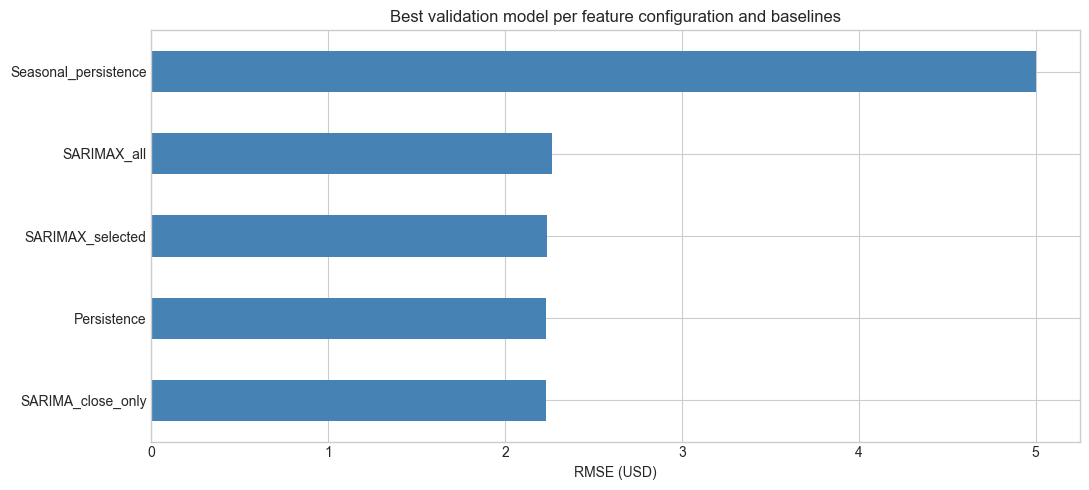

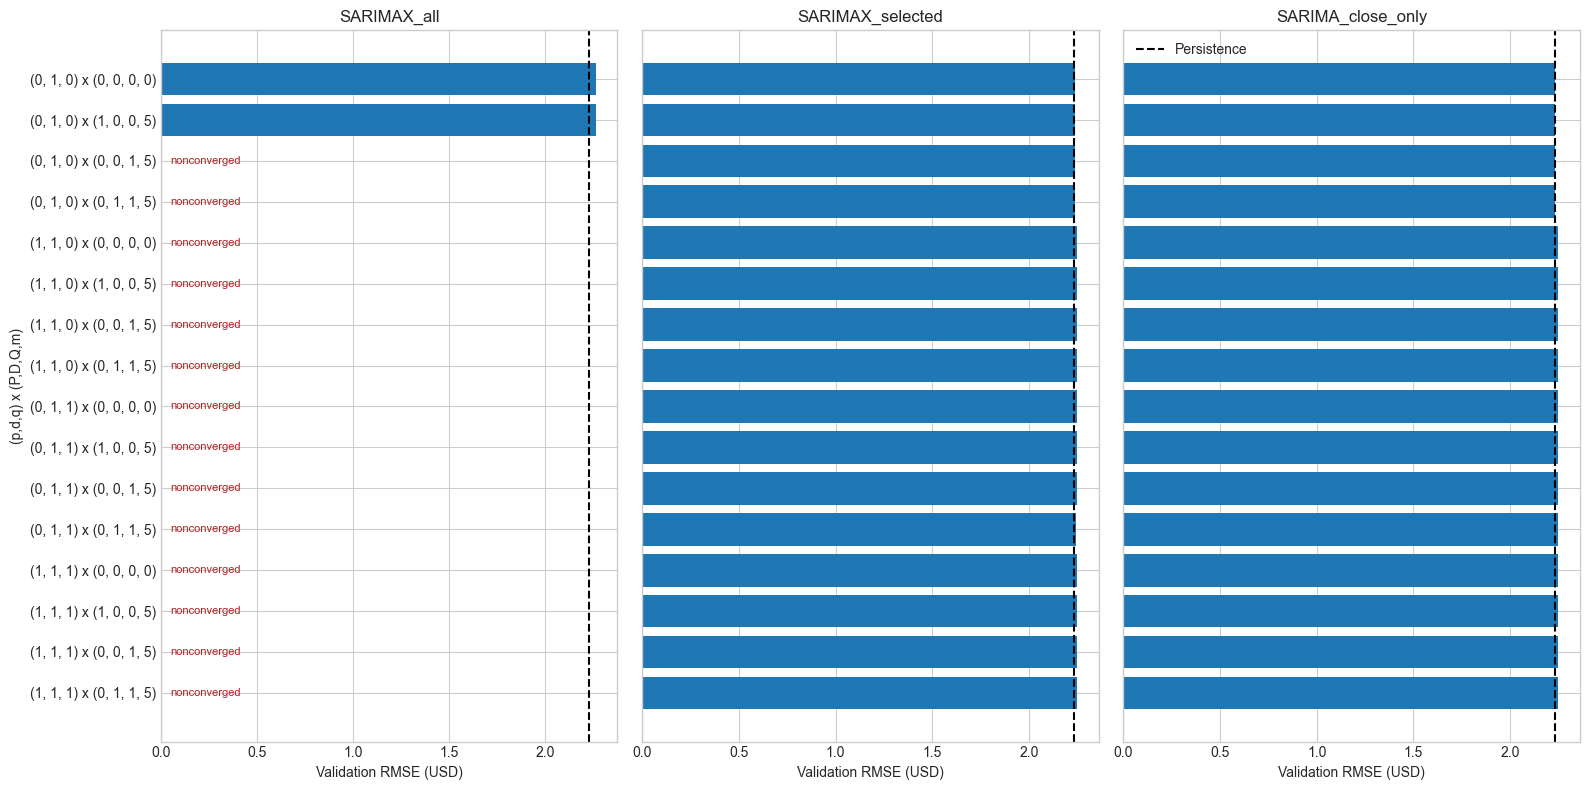

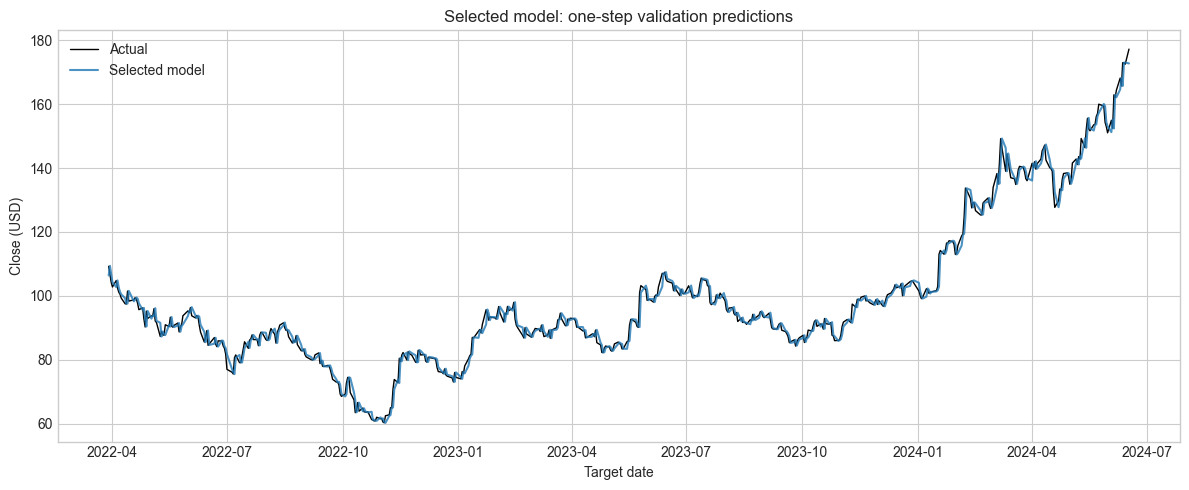

In [8]:
eligible = results.loc[(results['status'] == 'ok') & np.isfinite(results['RMSE'])].copy()
if eligible.empty:
    raise RuntimeError('No eligible model. Inspect validation_grid.csv; do not proceed to test selection.')
ranked = eligible.sort_values(['RMSE', 'MAE', 'n_parameters', 'candidate']).reset_index(drop=True)
best = ranked.iloc[0]
BEST_NAME = str(best['configuration'])
BEST_ORDER = (int(best['p']), int(best['d']), int(best['q']))
BEST_SEASONAL_ORDER = (int(best['P']), int(best['D']), int(best['Q']), int(best['m']))
BEST_COLUMNS = FEATURE_SETS[BEST_NAME]
BEST_KEY = str(best['candidate'])
family_winners = ranked.groupby('configuration', sort=False).head(1)
display(family_winners[['configuration', 'p', 'd', 'q', 'P', 'D', 'Q', 'm', 'RMSE', 'MAE', 'R2', 'RMSE_skill_pct']])
comparison = family_winners.set_index('configuration')[['MAE', 'MSE', 'RMSE', 'MAPE_pct',
               'R2', 'MASE', 'Direction_accuracy_pct', 'RMSE_skill_pct']].copy()
comparison.loc['Persistence'] = pd.Series(baseline_validation)
comparison.loc['Seasonal_persistence'] = pd.Series(seasonal_baseline_validation)
display(comparison)
comparison.to_csv(RUN_DIR / 'validation_best_by_configuration.csv')

print(f'Selected model: {BEST_NAME}, order={BEST_ORDER}, seasonal_order={BEST_SEASONAL_ORDER}')
if not bool(best['has_seasonality']):
    print('A nonseasonal control won. This search does not support adding seasonal terms.')
seasonal_comparison = ranked.groupby(['configuration', 'has_seasonality'], sort=False).head(1)
display(seasonal_comparison[['configuration', 'has_seasonality', 'p', 'd', 'q', 'P', 'D', 'Q', 'm', 'RMSE']])
seasonal_comparison.to_csv(RUN_DIR / 'seasonal_vs_nonseasonal.csv', index=False)
print(f"Validation RMSE: {best['RMSE']:.6f} USD; persistence: {baseline_validation['RMSE']:.6f} USD")
if best['RMSE'] >= baseline_validation['RMSE']:
    print('Persistence is at least as good on validation. No forecasting improvement is established.')
else:
    print(f"Validation RMSE improvement over persistence: {best['RMSE_skill_pct']:.3f}%")
for name in FEATURE_SETS:
    if name not in family_winners['configuration'].values:
        print(f'LIMITATION: {name} produced no eligible candidate.')


fig, ax = plt.subplots(figsize=(11, 5))
comparison['RMSE'].sort_values().plot.barh(ax=ax, color='steelblue')
ax.set(title='Best validation model per feature configuration and baselines', xlabel='RMSE (USD)', ylabel='')
finish_plot('05_validation_comparison')

grid_labels = [f'{order} x {seasonal}' for order, seasonal in MODEL_GRID]
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)
for ax, name in zip(axes, FEATURE_SETS):
    table = results.loc[results['configuration'] == name].set_index('grid_id').reindex(range(len(MODEL_GRID)))
    good = table['status'].eq('ok').to_numpy()
    rmse_values = table['RMSE'].to_numpy(dtype=float)
    ax.barh(np.arange(len(MODEL_GRID))[good], rmse_values[good])
    for i in np.flatnonzero(~good):
        ax.text(0.02, i, str(table.iloc[i]['status']), color='firebrick', fontsize=8,
                transform=ax.get_yaxis_transform(), va='center')
    ax.axvline(baseline_validation['RMSE'], color='black', linestyle='--', label='Persistence')
    ax.set(title=name, xlabel='Validation RMSE (USD)', yticks=np.arange(len(grid_labels)), yticklabels=grid_labels)
axes[0].invert_yaxis()
axes[0].set_ylabel('(p,d,q) x (P,D,Q,m)')
axes[-1].legend()
finish_plot('05b_full_seasonal_grid')

fig, ax = plt.subplots()
ax.plot(validation['Target_Date'], validation['Target_Close'], label='Actual', color='black', linewidth=1)
ax.plot(validation['Target_Date'], validation_forecasts[BEST_KEY], label='Selected model', alpha=0.8)
ax.set(title='Selected model: one-step validation predictions', xlabel='Target date', ylabel='Close (USD)')
ax.legend()
finish_plot('06_validation_forecast')


## 9. Refit the locked configuration and inspect innovations

Refit the selected ordinary order, seasonal order, and frozen feature list on training + validation. Refit scaling on that combined historical period. If this fit fails to converge, stop before test evaluation. Do not choose a replacement using test results.

Plot standardized one-step innovations after initialization burn-in, their histogram, normal Q–Q plot, and ACF. Ljung–Box diagnostics use lags 10 and 20 and adjust degrees of freedom by `p+q+P+Q`; these lags exceed the parameter count for the declared grid. Seasonal initialization is accounted for in burn-in. Remaining autocorrelation and non-normality are limitations, not an invitation to tune on the test period.


Final refit converged: True
Final refit warnings: []


,lb_stat,lb_pvalue
10,49.061719,1.616177e-07
20,99.392912,6.897127e-13


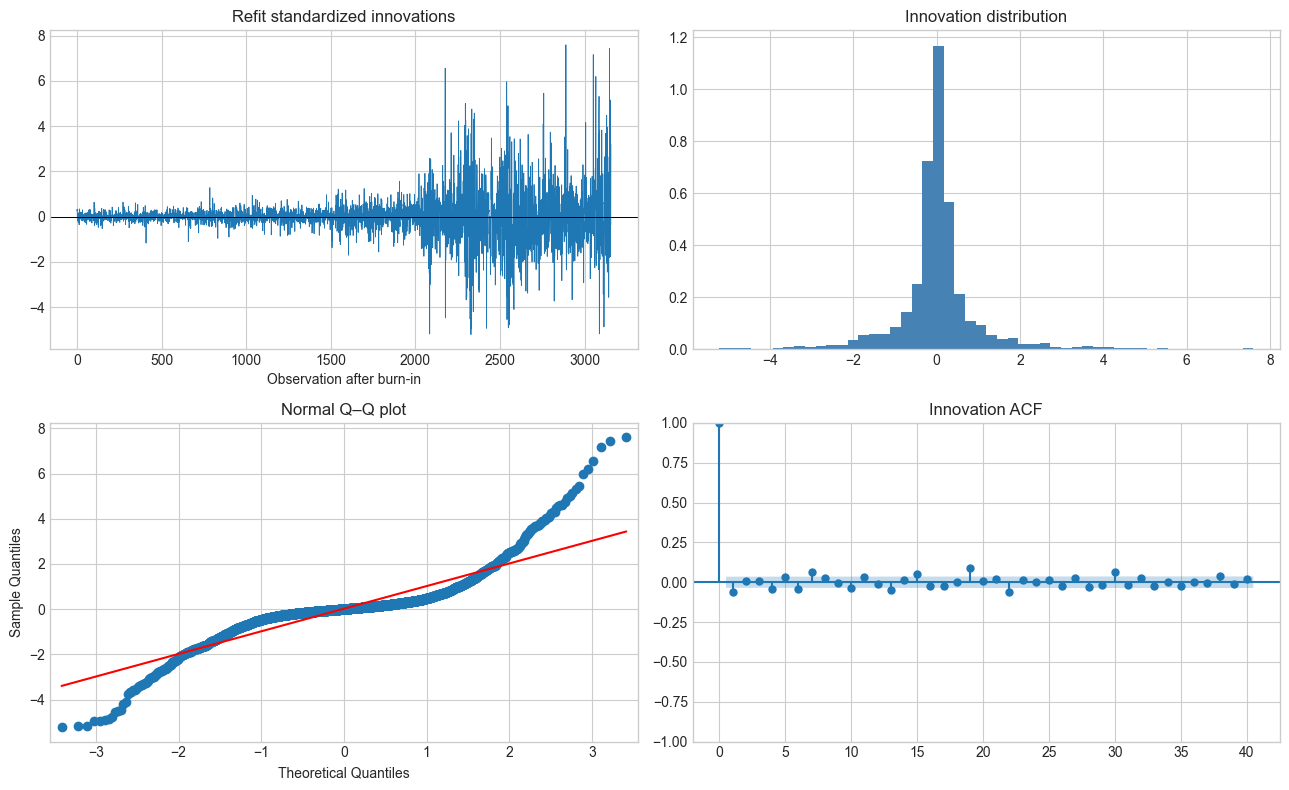

In [9]:
history = pd.concat([train, validation], ignore_index=True)
x_history, x_test, final_scaler = prepare_inputs(history, test, BEST_COLUMNS)
final_model, final_converged, final_warnings, final_fit_seconds = fit_candidate(
    history['Target_Close'], x_history, BEST_ORDER, BEST_SEASONAL_ORDER)
print('Final refit converged:', final_converged)
print('Final refit warnings:', final_warnings)
if not final_converged:
    raise RuntimeError('Locked model did not converge on train + validation. Test evaluation stopped.')

burn = max(int(final_model.loglikelihood_burn),
           BEST_ORDER[1] + BEST_SEASONAL_ORDER[1] * BEST_SEASONAL_ORDER[3],
           max(BEST_ORDER[0], BEST_ORDER[2]) +
           max(BEST_SEASONAL_ORDER[0], BEST_SEASONAL_ORDER[2]) * BEST_SEASONAL_ORDER[3], 1)
innovations = np.asarray(final_model.filter_results.standardized_forecasts_error)[0, burn:]
innovations = innovations[np.isfinite(innovations)]
ljung_box = acorr_ljungbox(innovations, lags=[10, 20],
                          model_df=BEST_ORDER[0] + BEST_ORDER[2] + BEST_SEASONAL_ORDER[0] + BEST_SEASONAL_ORDER[2], return_df=True)
display(ljung_box)
ljung_box.to_csv(RUN_DIR / 'refit_ljung_box.csv')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(innovations, linewidth=0.6)
axes[0, 0].axhline(0, color='black', linewidth=0.7)
axes[0, 0].set(title='Refit standardized innovations', xlabel='Observation after burn-in')
axes[0, 1].hist(innovations, bins=50, density=True, color='steelblue')
axes[0, 1].set_title('Innovation distribution')
qqplot(innovations, line='s', ax=axes[1, 0])
axes[1, 0].set_title('Normal Q–Q plot')
plot_acf(innovations, lags=40, ax=axes[1, 1])
axes[1, 1].set_title('Innovation ACF')
finish_plot('07_refit_residual_diagnostics')


## 10. Reserved test evaluation and forecast plots

Only the locked winner, persistence, and seasonal persistence are evaluated here. The rolling procedure may consume an earlier test actual after forecasting it, because that value would be available at the next forecast origin; it never uses a later actual to forecast an earlier date. We do not select orders, features, or thresholds from test results.

The 95% intervals are conditional model-based intervals from Statsmodels. They do not include all parameter uncertainty and are not a guarantee of coverage. We measure actual test coverage and mean interval width. A 20-observation rolling MAE plot shows whether error varies across periods.

**Existing-project limitation:** the original ARIMA and naïve notebooks already displayed results for part of this historical test period. This is a reproducible held-out evaluation for the current procedure, but cannot honestly be described as a never-before-seen research sample. A later untouched period would be needed for a stronger final confirmation.


,MAE,MSE,RMSE,MAPE_pct,R2,MASE,Direction_accuracy_pct,RMSE_skill_pct
model,,,,,,,,
SARIMA_close_only,5.234358,54.747109,7.399129,1.96939,0.993497,6.612481,49.373882,0.028935
Persistence,5.232576,54.778805,7.401270,1.96797,0.993493,6.610230,0.178891,0.000000
Seasonal_persistence,10.354741,178.799900,13.371608,4.00090,0.978761,13.080979,52.951699,-80.666387


95% interval empirical coverage: 40.43%
Mean interval width: $5.5334


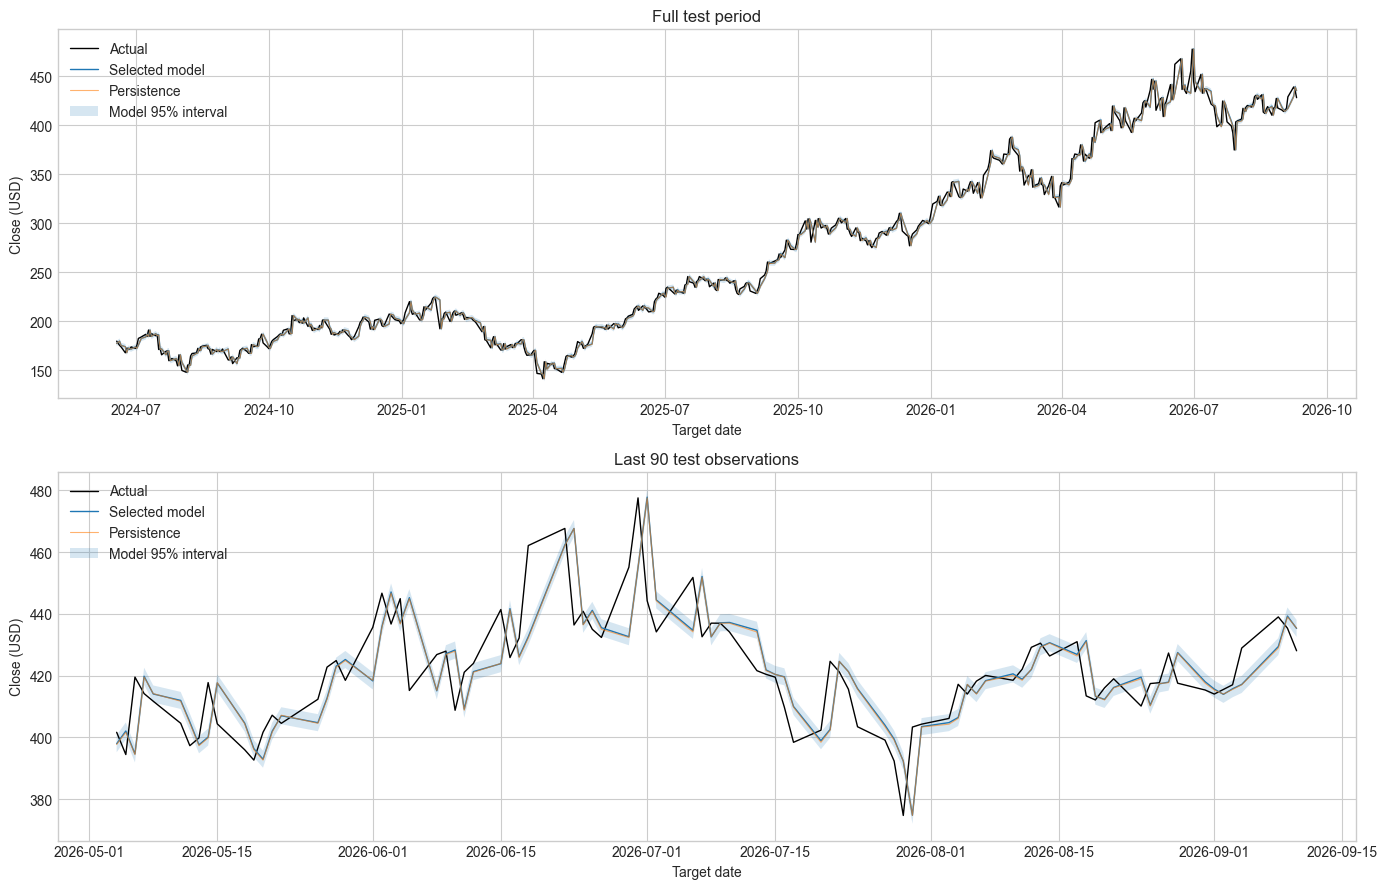

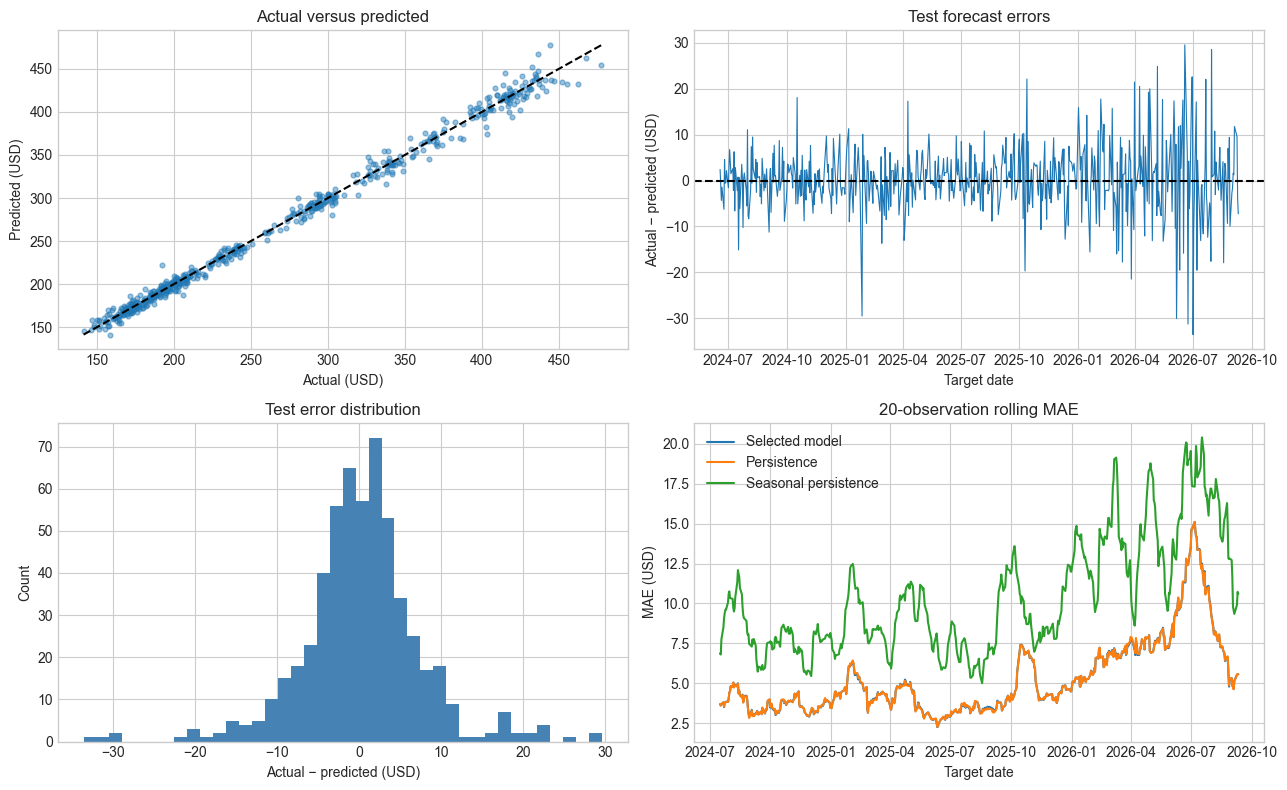

In [10]:
test_predictions, test_lower, test_upper = walk_forward(final_model, test, x_test, intervals=True)
test_metrics = pd.DataFrame({
    BEST_NAME: score(test, test_predictions, history),
    'Persistence': score(test, test['Close'].to_numpy(), history),
    'Seasonal_persistence': score(test, seasonal_persistence(test), history)
}).T
test_metrics.index.name = 'model'
display(test_metrics)
test_metrics.to_csv(RUN_DIR / 'test_metrics.csv')

test_export = test[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
test_export['Prediction'] = test_predictions
test_export['Persistence'] = test['Close'].to_numpy()
test_export['Seasonal_persistence'] = seasonal_persistence(test)
test_export['Lower_95'] = test_lower
test_export['Upper_95'] = test_upper
test_export['Error_actual_minus_predicted'] = test_export['Target_Close'] - test_predictions
test_export['Predicted_return'] = test_predictions / test_export['Close'] - 1
test_export['Actual_return'] = test_export['Target_Close'] / test_export['Close'] - 1
assert (test_lower <= test_upper).all()
assert np.isfinite(test_lower).all() and np.isfinite(test_upper).all()
coverage = float(np.mean((test['Target_Close'].to_numpy() >= test_lower) &
                         (test['Target_Close'].to_numpy() <= test_upper)) * 100)
mean_width = float(np.mean(test_upper - test_lower))
print(f'95% interval empirical coverage: {coverage:.2f}%')
print(f'Mean interval width: ${mean_width:.4f}')
test_export.to_csv(RUN_DIR / 'test_predictions.csv', index=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, frame, title in [(axes[0], test_export, 'Full test period'),
                         (axes[1], test_export.tail(90), 'Last 90 test observations')]:
    ax.plot(frame['Target_Date'], frame['Target_Close'], color='black', label='Actual', linewidth=1)
    ax.plot(frame['Target_Date'], frame['Prediction'], label='Selected model', linewidth=1)
    ax.plot(frame['Target_Date'], frame['Persistence'], label='Persistence', alpha=0.6, linewidth=0.8)
    ax.fill_between(frame['Target_Date'], frame['Lower_95'], frame['Upper_95'],
                    alpha=0.18, label='Model 95% interval')
    ax.set(title=title, xlabel='Target date', ylabel='Close (USD)')
    ax.legend(loc='upper left')
finish_plot('08_test_forecasts')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].scatter(test_export['Target_Close'], test_predictions, alpha=0.45, s=12)
limits = [min(test_export['Target_Close'].min(), test_predictions.min()),
          max(test_export['Target_Close'].max(), test_predictions.max())]
axes[0, 0].plot(limits, limits, '--', color='black')
axes[0, 0].set(title='Actual versus predicted', xlabel='Actual (USD)', ylabel='Predicted (USD)')
axes[0, 1].plot(test_export['Target_Date'], test_export['Error_actual_minus_predicted'], linewidth=0.8)
axes[0, 1].axhline(0, color='black', linestyle='--')
axes[0, 1].set(title='Test forecast errors', xlabel='Target date', ylabel='Actual − predicted (USD)')
axes[1, 0].hist(test_export['Error_actual_minus_predicted'], bins=40, color='steelblue')
axes[1, 0].set(title='Test error distribution', xlabel='Actual − predicted (USD)', ylabel='Count')
for column, label in [('Prediction', 'Selected model'), ('Persistence', 'Persistence'),
                       ('Seasonal_persistence', 'Seasonal persistence')]:
    rolling_mae = (test_export['Target_Close'] - test_export[column]).abs().rolling(20).mean()
    axes[1, 1].plot(test_export['Target_Date'], rolling_mae, label=label)
axes[1, 1].set(title='20-observation rolling MAE', xlabel='Target date', ylabel='MAE (USD)')
axes[1, 1].legend()
finish_plot('09_test_error_analysis')


## 11. Save and reload the selected model

Each run gets a unique folder under `models/sarima/`, so previous results are preserved. `selected_model.pkl` contains the locked model fitted on train + validation **before test observation updates**. `preprocessing.joblib` contains the scaler, feature order, and transformation metadata. `manifest.json` records the data hash, package versions, target definition, split dates, candidate grid, selection rule, and diagnostics. Prediction and metric CSVs plus PNG plots accompany the model.

The reload check reproduces the first test forecast using only its origin features. This verifies that saving retains both the fitted parameters/state and the input preprocessing. The saved model's state belongs to its recorded cutoff; before forecasting from a later origin, supply each subsequently observed target and its correctly aligned origin features through `extend`, or refit under a separately documented deployment procedure. Do not pass the newest row directly to an old model state and call it the next-day forecast. Load pickle/joblib artifacts only from trusted sources.

The manifest also records seasonal orders, selector settings, and the frozen selected feature list. Only loading the saved scaler and selected inputs is required for inference; the selector is not rerun at each forecast. The `latest_run.json` pointer is written only after the final summary cell completes.


In [11]:
MODEL_FILE = RUN_DIR / 'selected_model.pkl'
PREPROCESSOR_FILE = RUN_DIR / 'preprocessing.joblib'
final_model.save(MODEL_FILE)
preprocessing = {'scaler': final_scaler, 'features': BEST_COLUMNS,
                 'transforms': {'Volume': 'log1p'} if 'Volume' in BEST_COLUMNS else {},
                 'target': 'Next observed trading day unadjusted Close',
                 'forecast_origin': 'After current trading day market close',
                 'last_training_target_date': str(history['Target_Date'].max().date())}
joblib.dump(preprocessing, PREPROCESSOR_FILE)

reloaded_model = SARIMAXResults.load(MODEL_FILE)
reloaded_preprocessing = joblib.load(PREPROCESSOR_FILE)
if BEST_COLUMNS:
    reload_x = reloaded_preprocessing['scaler'].transform(
        feature_values(test.iloc[:1], reloaded_preprocessing['features']))
else:
    reload_x = None
reload_prediction = float(np.asarray(reloaded_model.forecast(steps=1, exog=reload_x)).reshape(-1)[0])
np.testing.assert_allclose(reload_prediction, test_predictions[0], rtol=1e-9, atol=1e-9)
print('Saved-model reload check passed.')

manifest = {
    'run_id': RUN_ID, 'source_file': str(DATA_FILE.relative_to(ROOT)),
    'source_sha256': hashlib.sha256(DATA_FILE.read_bytes()).hexdigest(),
    'provenance': 'Master built from local Yahoo Finance data; local Google Finance comparison available.',
    'raw_rows': len(raw), 'raw_columns': len(raw.columns), 'usable_rows': len(data),
    'raw_start': str(raw['Date'].min().date()), 'raw_end': str(raw['Date'].max().date()),
    'target': 'Close[t+1]', 'inputs': 'Features observable after Close[t]',
    'feature_sets': FEATURE_SETS, 'excluded_columns': EXCLUDED,
    'splits': json.loads(split_summary.to_json(orient='records', date_format='iso')),
    'order_grid': ORDER_GRID, 'seasonal_grid': SEASONAL_GRID,
    'feature_selection': {'method': 'ElasticNet with expanding chronological CV on training returns',
                          'best_params': selector_search.best_params_, 'folds': 3, 'gap': 1,
                          'alpha_grid': SELECTOR_ALPHAS, 'l1_ratio_grid': SELECTOR_L1_RATIOS,
                          'coefficient_tolerance': SELECTOR_COEF_TOL,
                          'warnings': selector_warning_text}, 'trend': TREND, 'max_optimizer_iterations': MAX_ITER,
    'protocol': 'Fit once per split origin; one-step forecast then extend state with actual; no parameter refits.',
    'selection': 'Converged validation RMSE, then MAE, then parameter count, then candidate name.',
    'selected_configuration': BEST_NAME, 'selected_order': BEST_ORDER,
    'selected_seasonal_order': BEST_SEASONAL_ORDER,
    'seasonality_selected': bool(best['has_seasonality']),
    'selected_features': BEST_COLUMNS, 'validation_metrics': {k: float(best[k]) for k in baseline_validation},
    'validation_persistence_metrics': baseline_validation,
    'validation_seasonal_persistence_metrics': seasonal_baseline_validation,
    'test_metrics': json.loads(test_metrics.to_json(orient='index')),
    'test_interval_coverage_pct': coverage, 'test_mean_interval_width_usd': mean_width,
    'final_converged': final_converged, 'final_fit_warnings': final_warnings,
    'final_fit_seconds': final_fit_seconds,
    'saved_model_state': 'Train + validation cutoff, before test updates',
    'prior_test_exposure': 'Original project notebooks already evaluated part of this period.',
    'versions': {'python': platform.python_version(), 'numpy': np.__version__,
                 'pandas': pd.__version__, 'scipy': scipy.__version__,
                 'statsmodels': statsmodels.__version__, 'sklearn': sklearn.__version__,
                 'joblib': joblib.__version__},
}
(RUN_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2, allow_nan=False), encoding='utf-8')
print('Model and all experiment artifacts saved in:', RUN_DIR)


Saved-model reload check passed.
Model and all experiment artifacts saved in: f:\SEM-7\Time Series Analysis\Project\models\sarima\20260923T033954075995Z


## 12. Report-ready interpretation

The generated summary below uses actual results from this execution. It distinguishes validation-based selection from final test performance. Include the complete grid and failed fits in the report rather than showing only favorable candidates. No forecasting metric here establishes profitability; that requires a separate chronological strategy experiment with realistic execution timing and costs.

To adapt this notebook for another model family, preserve the target dates, data-availability rules, baseline, evaluation metrics, and reserved test procedure. Model-specific hyperparameters can differ across families, but the all-feature and curated-feature variants within each family should receive a comparable search budget.


In [12]:
selected_test = test_metrics.loc[BEST_NAME]
baseline_test = test_metrics.loc['Persistence']
validation_verdict = ('beat persistence on validation' if best['RMSE'] < baseline_validation['RMSE']
                      else 'did not beat persistence on validation')
test_verdict = ('beat persistence on the reserved test period' if selected_test['RMSE'] < baseline_test['RMSE']
                else 'did not beat persistence on the reserved test period')
summary = f'''# SARIMA / SARIMAX experiment results

- Data: {len(raw):,} source rows, {len(data):,} aligned complete observations; next-trading-day Close in USD.
- Selected configuration: **{BEST_NAME}**, ordinary order **{BEST_ORDER}**, seasonal order **{BEST_SEASONAL_ORDER}**, {len(BEST_COLUMNS)} exogenous features.
- Seasonal terms selected: **{bool(best['has_seasonality'])}**. A nonseasonal winner means seasonality was not justified within this grid.
- Feature screening retained **{len(SELECTED_FEATURES)}** inputs using training-only cross-validation.
- Selection reason: lowest validation RMSE among converged candidates under the common grid and evaluation protocol.
- Validation: RMSE **${best['RMSE']:.4f}**, MAE **${best['MAE']:.4f}**; persistence RMSE **${baseline_validation['RMSE']:.4f}**. The selected model {validation_verdict}.
- Test: MSE **{selected_test['MSE']:.4f} USD²**, RMSE **${selected_test['RMSE']:.4f}**, MAE **${selected_test['MAE']:.4f}**, MAPE **{selected_test['MAPE_pct']:.3f}%**, R² **{selected_test['R2']:.5f}**.
- Test persistence RMSE: **${baseline_test['RMSE']:.4f}**. The selected model {test_verdict}.
- Seasonal-persistence test RMSE: **${test_metrics.loc['Seasonal_persistence', 'RMSE']:.4f}**.
- Test direction accuracy: **{selected_test['Direction_accuracy_pct']:.2f}%**; this is not a profitability metric.
- Test model-interval coverage: **{coverage:.2f}%** for nominal 95% intervals.
- Eligible candidates: **{len(eligible)} / {len(results)}**. Review warnings and design collinearity before interpreting coefficients.
- Limitations: single historical validation window, an approximate five-trading-row season, proxy linear feature screening, fixed coefficients within each evaluation period, possible regime changes, conditional Gaussian intervals, and prior project exposure to part of the test period. Small RMSE differences are not evidence of statistical significance.
- Profitability evaluation is deferred. This experiment makes no claim that the selected forecasting model maximizes profit.
'''
display(Markdown(summary))
(RUN_DIR / 'summary.md').write_text(summary, encoding='utf-8')

(ROOT / 'models' / 'sarima' / 'latest_run.json').write_text(
    json.dumps({'run_id': RUN_ID, 'directory': str(RUN_DIR.relative_to(ROOT))}, indent=2), encoding='utf-8')
print('Run complete:', RUN_DIR)


# SARIMA / SARIMAX experiment results

- Data: 3,771 source rows, 3,721 aligned complete observations; next-trading-day Close in USD.
- Selected configuration: **SARIMA_close_only**, ordinary order **(0, 1, 0)**, seasonal order **(0, 1, 1, 5)**, 0 exogenous features.
- Seasonal terms selected: **True**. A nonseasonal winner means seasonality was not justified within this grid.
- Feature screening retained **3** inputs using training-only cross-validation.
- Selection reason: lowest validation RMSE among converged candidates under the common grid and evaluation protocol.
- Validation: RMSE **$2.2310**, MAE **$1.6117**; persistence RMSE **$2.2317**. The selected model beat persistence on validation.
- Test: MSE **54.7471 USD²**, RMSE **$7.3991**, MAE **$5.2344**, MAPE **1.969%**, R² **0.99350**.
- Test persistence RMSE: **$7.4013**. The selected model beat persistence on the reserved test period.
- Seasonal-persistence test RMSE: **$13.3716**.
- Test direction accuracy: **49.37%**; this is not a profitability metric.
- Test model-interval coverage: **40.43%** for nominal 95% intervals.
- Eligible candidates: **34 / 48**. Review warnings and design collinearity before interpreting coefficients.
- Limitations: single historical validation window, an approximate five-trading-row season, proxy linear feature screening, fixed coefficients within each evaluation period, possible regime changes, conditional Gaussian intervals, and prior project exposure to part of the test period. Small RMSE differences are not evidence of statistical significance.
- Profitability evaluation is deferred. This experiment makes no claim that the selected forecasting model maximizes profit.


Run complete: f:\SEM-7\Time Series Analysis\Project\models\sarima\20260923T033954075995Z
